Population Pyramid of One State

In [42]:
import pandas as pd

population_data = pd.read_csv("population_state.csv")
population_data.head()

,state,date,sex,age,ethnicity,population
0,Johor,1970-01-01,both,overall,overall,1325.6
1,Johor,1970-01-01,both,0-4,overall,210.1
2,Johor,1970-01-01,both,5-9,overall,215.7
3,Johor,1970-01-01,both,10-14,overall,192.2
4,Johor,1970-01-01,both,15-19,overall,152.8


In [43]:
population_data["year"] = pd.to_datetime(population_data["date"]).dt.year
population_data.head()

,state,date,sex,age,ethnicity,population,year
0,Johor,1970-01-01,both,overall,overall,1325.6,1970
1,Johor,1970-01-01,both,0-4,overall,210.1,1970
2,Johor,1970-01-01,both,5-9,overall,215.7,1970
3,Johor,1970-01-01,both,10-14,overall,192.2,1970
4,Johor,1970-01-01,both,15-19,overall,152.8,1970


Plot for Sarawak, 2010 first

In [44]:
population_data_pyramid = population_data[
    (population_data["state"] == "Sarawak") &
    (population_data["year"] == 2010) &
    (population_data["age"] != "overall") &
    (population_data["ethnicity"] == "overall") &
    (population_data["sex"] != "both")
][["age", "sex", "population"]].copy()

In [45]:
population_data_pyramid.head()

,age,sex,population
185321,0-4,female,111.0
185328,5-9,female,123.8
185335,10-14,female,120.5
185342,15-19,female,121.8
185349,20-24,female,115.0


In [47]:
population_data_pyramid["age_order"] = population_data_pyramid["age"].str.extract(r"(\d+)").astype(int)
population_data_pyramid = population_data_pyramid.sort_values("age_order")
population_data_pyramid

,age,sex,population,age_order
185321,0-4,female,111.0,0
185454,0-4,male,113.8,0
185461,5-9,male,127.7,5
185328,5-9,female,123.8,5
185335,10-14,female,120.5,10
185468,10-14,male,122.1,10
185475,15-19,male,127.4,15
185342,15-19,female,121.8,15
185349,20-24,female,115.0,20
185482,20-24,male,120.9,20


In [48]:
age_order = population_data_pyramid["age"].unique()
population_data_pyramid_table = population_data_pyramid.pivot_table(
                                    index = "age", columns="sex", values="population").fillna(0)
population_data_pyramid_table = population_data_pyramid_table.reindex(age_order)
population_data_pyramid_table

sex,female,male
age,,
0-4,111.0,113.8
5-9,123.8,127.7
10-14,120.5,122.1
15-19,121.8,127.4
20-24,115.0,120.9
25-29,98.0,113.9
30-34,80.5,90.7
35-39,82.1,90.0
40-44,75.6,84.6


In [49]:
population_data_pyramid_table["male"] = -population_data_pyramid_table["male"]
population_data_pyramid_table

sex,female,male
age,,
0-4,111.0,-113.8
5-9,123.8,-127.7
10-14,120.5,-122.1
15-19,121.8,-127.4
20-24,115.0,-120.9
25-29,98.0,-113.9
30-34,80.5,-90.7
35-39,82.1,-90.0
40-44,75.6,-84.6


C:\Users\Acer\AppData\Local\Temp\ipykernel_5428\2369412481.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([abs(int(x)) for x in xticks])


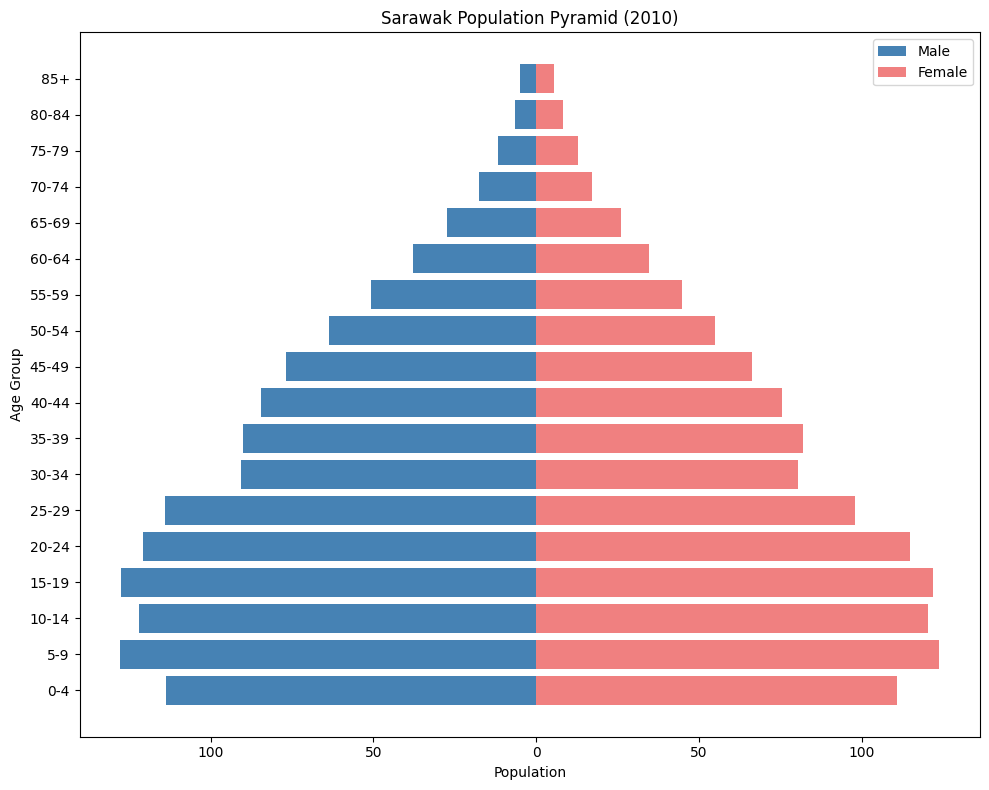

In [50]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(population_data_pyramid_table.index, population_data_pyramid_table["male"], color="steelblue", label="Male")
ax.barh(population_data_pyramid_table.index, population_data_pyramid_table["female"], color="lightcoral", label="Female")

ax.set_title("Sarawak Population Pyramid (2010)")
ax.set_xlabel("Population")
ax.set_ylabel("Age Group")

# Make x-axis labels positive
xticks = ax.get_xticks()
ax.set_xticklabels([abs(int(x)) for x in xticks])

ax.legend()
plt.tight_layout()
plt.show()

Plot for any state for valid years

C:\Users\Acer\AppData\Local\Temp\ipykernel_5428\299834577.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([abs(int(x)) for x in xticks])


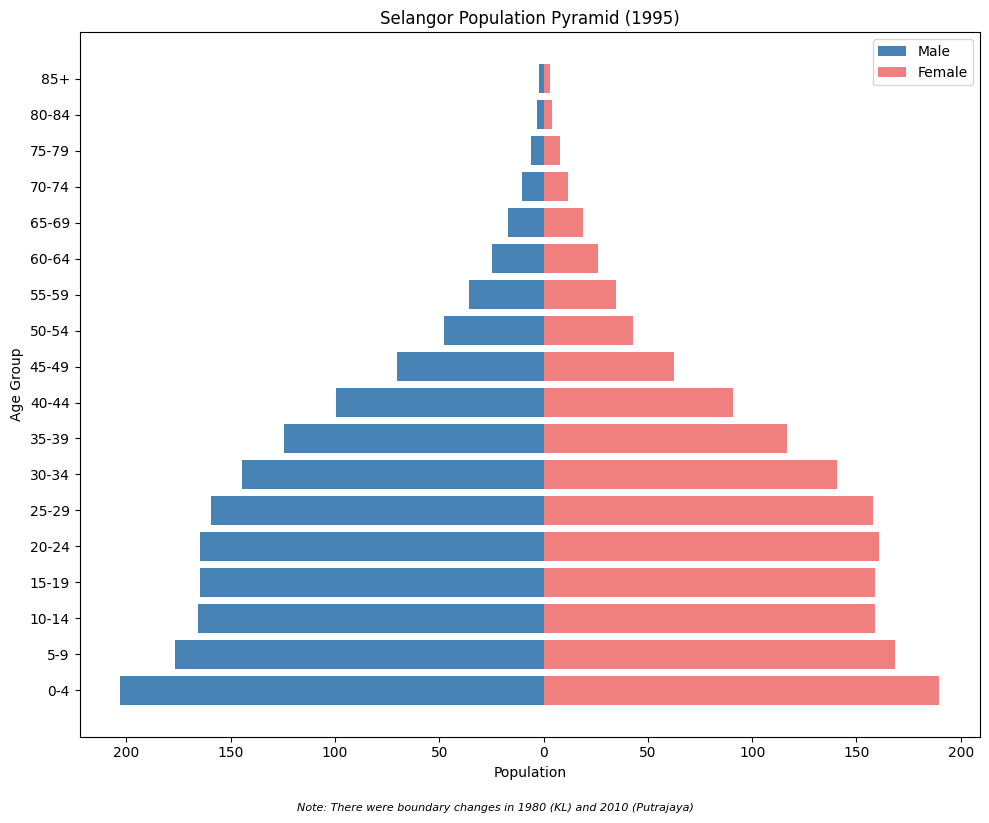

In [54]:
def data_pyramid_state_by_year(state, year):
    population_data_pyramid = population_data[
        (population_data["state"] == state) &
        (population_data["year"] == year) &
        (population_data["age"] != "overall") &
        (population_data["ethnicity"] == "overall") &
        (population_data["sex"] != "both")
    ][["age", "sex", "population"]].copy()

    population_data_pyramid["age_order"] = population_data_pyramid["age"].str.extract(r"(\d+)").astype(int)
    population_data_pyramid = population_data_pyramid.sort_values("age_order")

    age_order = population_data_pyramid["age"].unique()
    population_data_pyramid_table = population_data_pyramid.pivot_table(
                                    index = "age", columns="sex", values="population").fillna(0)
    population_data_pyramid_table = population_data_pyramid_table.reindex(age_order)
    
    return population_data_pyramid_table

def plot_state_population_pyramid_year(state, year):
    population_data_pyramid_table = data_pyramid_state_by_year(state, year)
    population_data_pyramid_table["male"] = -population_data_pyramid_table["male"]
    
    fig, ax = plt.subplots(figsize=(10, 8))

    ax.barh(population_data_pyramid_table.index, population_data_pyramid_table["male"], color="steelblue", label="Male")
    ax.barh(population_data_pyramid_table.index, population_data_pyramid_table["female"], color="lightcoral", label="Female")

    ax.set_title(f"{state} Population Pyramid ({year})")
    ax.set_xlabel("Population")
    ax.set_ylabel("Age Group")

    xticks = ax.get_xticks()
    ax.set_xticklabels([abs(int(x)) for x in xticks])

    if state == "Selangor":
        plt.figtext(
            0.5, -0.02, 
            "Note: There were boundary changes in 1980 (KL) and 2010 (Putrajaya)",
            wrap=True, ha='center', fontsize=8, style='italic'
        ) 
    elif state == "Sabah":
        plt.figtext(
            0.5, -0.02, 
            "Note: There was a boundary change in 1991 (Labuan)",
            wrap=True, ha='center', fontsize=8, style='italic'
        )

    ax.legend()
    plt.tight_layout()
    plt.show()

plot_state_population_pyramid_year("Selangor", 1995)